# Data Preprocessing: PCATransform and ZScoreTransform

`sc_flow.preprocessing` provides two sklearn-style transformers that work on
**numpy arrays**


In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sc_flow.preprocessing import PCATransform, ZScoreTransform
from sc_flow.dataset.toy_data import get_toy_dataset

## 1. Toy dataset


In [11]:
# Blobs with 50 features — enough to see PCA compression
adata = get_toy_dataset("blobs", n_samples=800, n_features=50, centers=4, random_state=42).adata

# Both transformers expect plain 2-D numpy arrays
X = np.array(adata.X, dtype=np.float64)  # shape (n_samples, 50)
labels = np.array(adata.obsm["Y"]).ravel()
print(f"X.shape: {X.shape}   dtype: {X.dtype}")

X.shape: (800, 50)   dtype: float64


## 2. ZScoreTransform

Standardises each feature independently: `z = (x - mean) / (std + epsilon)`.


In [12]:
zscore = ZScoreTransform()
X_norm = zscore.fit_transform(X)

print(f"Before — mean: {zscore.params.mean[:5].round(2)}  std: {zscore.params.std[:5].round(2)}")
print(f"After  — mean: {X_norm.mean(axis=0)[:5].round(4)}  std: {X_norm.std(axis=0)[:5].round(4)}")

Before — mean: [1.39 3.01 0.6  2.43 3.23]  std: [7.74 5.32 6.43 3.43 6.62]
After  — mean: [-0.  0.  0. -0. -0.]  std: [1. 1. 1. 1. 1.]


In [13]:
# ZScoreParams: all learned parameters stored after fit
p = zscore.params

print(f"is_fitted:  {p.is_fitted}")
print(f"n_features: {p.n_features}")
print(f"mean (first 5): {p.mean[:5].round(4)}")
print(f"std  (first 5): {p.std[:5].round(4)}")

is_fitted:  True
n_features: 50
mean (first 5): [1.3933 3.0067 0.6048 2.4253 3.2307]
std  (first 5): [7.7439 5.3249 6.431  3.4277 6.6183]


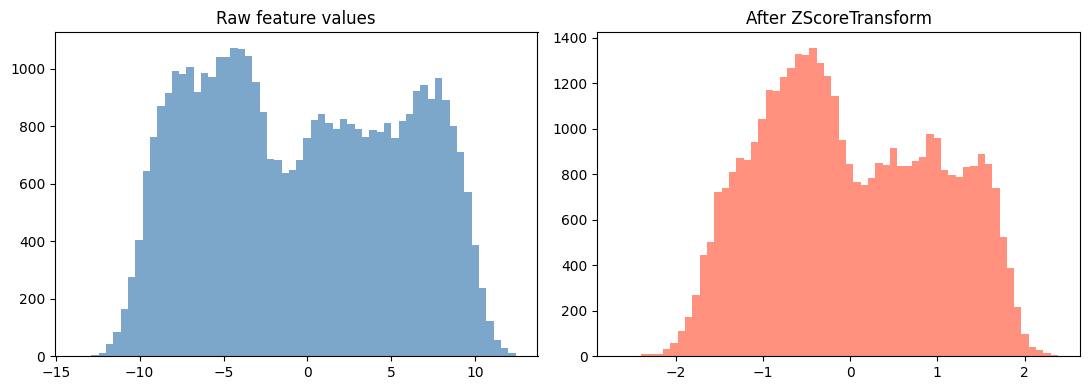

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(X.ravel(), bins=60, color="steelblue", alpha=0.7)
axes[0].set_title("Raw feature values")
axes[1].hist(X_norm.ravel(), bins=60, color="tomato", alpha=0.7)
axes[1].set_title("After ZScoreTransform")
plt.tight_layout()
plt.show()

In [15]:
# Inverse transform — exact reconstruction
X_reconstructed = zscore.inverse_transform(X_norm)
mse = np.mean((X - X_reconstructed) ** 2)
print(f"Reconstruction MSE: {mse:.2e}  (should be ~0)")

Reconstruction MSE: 1.03e-31  (should be ~0)


## 3. PCATransform

Reduces dimensionality by projecting onto the top-k principal components.


In [ ]:
pca = PCATransform(n_components=10)
X_pca = pca.fit_transform(X)

print(f"Input shape:  {X.shape}")
print(f"Output shape: {X_pca.shape}")
print(f"Explained variance (top 5): {pca.explained_variance_ratio()[:5].round(3)}")

Input shape:  (800, 50)
Output shape: (800, 10)
Explained variance (top 5): [0.394 0.306 0.294 0.001 0.001]


In [17]:
# PCAParams: all learned parameters stored after fit
p = pca.params

print(f"is_fitted:       {p.is_fitted}")
print(f"n_features:      {p.n_features}")
print(f"n_components:    {p.n_components}")
print(f"mean (first 5):  {p.mean[:5].round(4)}")
print(f"components shape: {p.components.shape}  (n_components x n_features)")
print(f"explained_variance (top 5): {p.explained_variance[:5].round(4)}")

is_fitted:       True
n_features:      50
n_components:    10
mean (first 5):  [1.3933 3.0067 0.6048 2.4253 3.2307]
components shape: (10, 50)  (n_components x n_features)
explained_variance (top 5): [543.6657 422.2481 406.07     1.5019   1.4443]


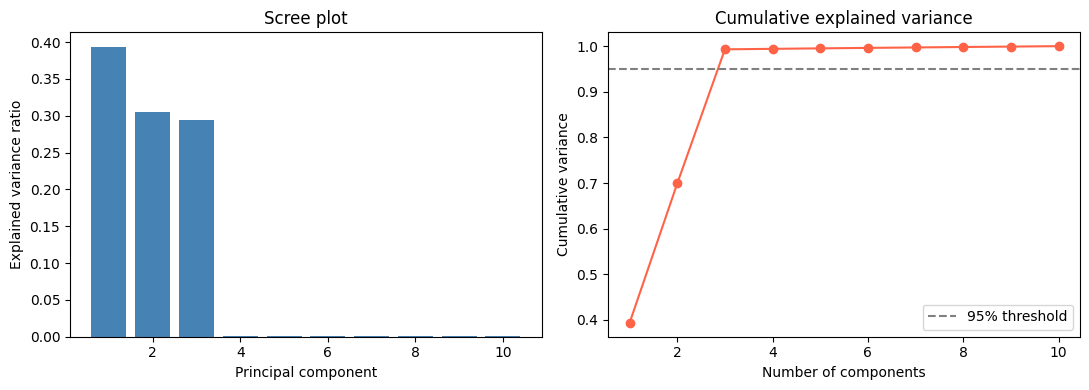

In [18]:
# Scree plot
evr = pca.explained_variance_ratio()
cumulative = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(range(1, len(evr) + 1), evr, color="steelblue")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot")
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker="o", color="tomato")
axes[1].axhline(0.95, ls="--", color="gray", label="95% threshold")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()
plt.tight_layout()
plt.show()

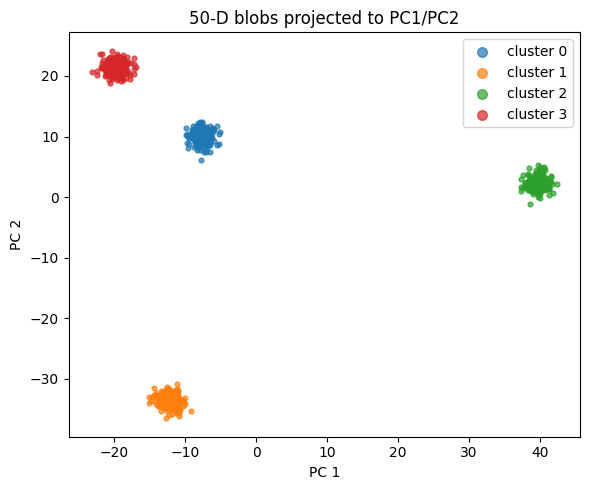

In [19]:
# Scatter in PC1/PC2 coloured by cluster label
plt.figure(figsize=(6, 5))
for lab in np.unique(labels):
    mask = labels == lab
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=12, alpha=0.7, label=f"cluster {lab}")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("50-D blobs projected to PC1/PC2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

In [20]:
# Inverse transform — lossy reconstruction
X_back = pca.inverse_transform(X_pca)
mse = np.mean((X - X_back) ** 2)
print(f"Reconstruction MSE (10 / 50 components): {mse:.4f}")

Reconstruction MSE (10 / 50 components): 0.7445
